In [ ]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from pandas.plotting import lag_plot
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred
from myeia import API
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.stattools import adfuller, grangercausalitytests, coint
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sktime.forecasting.all import temporal_train_test_split

In [ ]:
df = pd.read_csv('final_df.csv')

df = df.rename(columns={
    df.columns[0]: 'Date',
    'Brent_price': 'Brent',
    'world_crude_supply': 'production',
    'global_demand_proxy': 'demand'
})

df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 274 entries, 2003-01-01 to 2025-10-01
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Brent       274 non-null    float64
 1   production  274 non-null    float64
 2   demand      274 non-null    float64
dtypes: float64(3)
memory usage: 8.6 KB


In [ ]:
# Define ADF and KPSS test function
def check_stationarity(series, name=None, alpha=0.05, regression="c"):
    name = series.name
    s = series.dropna()

    print(f"\n===== {name} =====")

    # -------- ADF --------
    adf_stat, adf_p, _, _, _, _ = adfuller(s, regression=regression, autolag='AIC')

    # print("\nADF Test (H0: Non-Stationary)")
    print(f"ADF statistic: {adf_stat:.4f}, p-value: {adf_p:.4f}")

    # if adf_p < alpha:
    #     print("Reject H0: Likely Stationary\n")
    # else:
    #     print("Fail to Reject H0: Likely Non-Stationary\n")

    # -------- KPSS --------
    kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags="auto")

    # print("\nKPSS Test (H0: Stationary)")
    print(f"KPSS statistic: {kpss_stat:.4f}, p-value: {kpss_p:.4f}")

    # if kpss_p < alpha:
    #     print("Reject H0: Likely Non-Stationary\n")
    # else:
    #     print("Fail to Reject H0: Likely Stationary\n")

    # -------- Conclusion --------
    # print("\nOverall Interpretation:")

    if adf_p < alpha and kpss_p >= alpha:
        print("Strong evidence of stationarity")
    elif adf_p >= alpha and kpss_p < alpha:
        print("Strong evidence of non-stationarity")
    else:
        print("Mixed results — consider differencing or adding trend")

In [ ]:
# Define acf and pacf function
def plot_acf_pacf(series, lags=40, title=None):
    title = series.name
    s = series.dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plot_acf(s, lags=lags, ax=axes[0])
    axes[0].set_title(f"ACF - {title}")

    plot_pacf(s, lags=lags, ax=axes[1], method='ywm')
    axes[1].set_title(f"PACF - {title}")

    plt.tight_layout()
    plt.show()

# ARIMA/SARIMA on Brent

### Load Brent crude data

In [ ]:
fred = Fred(api_key='add api here')
# brent = fred.get_series('POILBREUSDM', observation_start='2003-01-01')
# brent = brent.asfreq('MS')  # monthly start frequency
# brent.name = 'Brent'
# brent.dropna(inplace=True)

brent = df['Brent']
brent.name = "Brent"

### Exploratory analysis


===== Brent =====
ADF statistic: -3.0633, p-value: 0.0294
KPSS statistic: 0.2759, p-value: 0.1000
Strong evidence of stationarity

===== Brent 1st Diff =====
ADF statistic: -11.2665, p-value: 0.0000
KPSS statistic: 0.0815, p-value: 0.1000
Strong evidence of stationarity


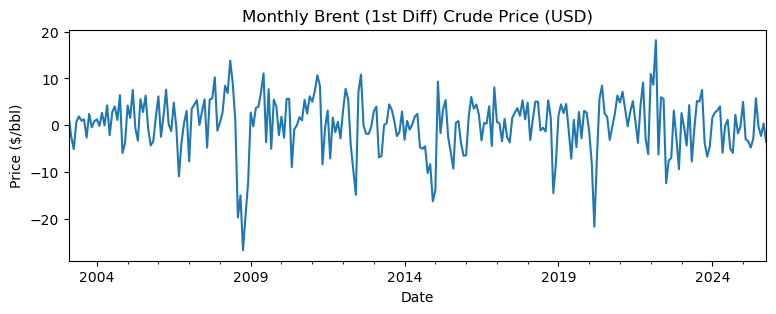

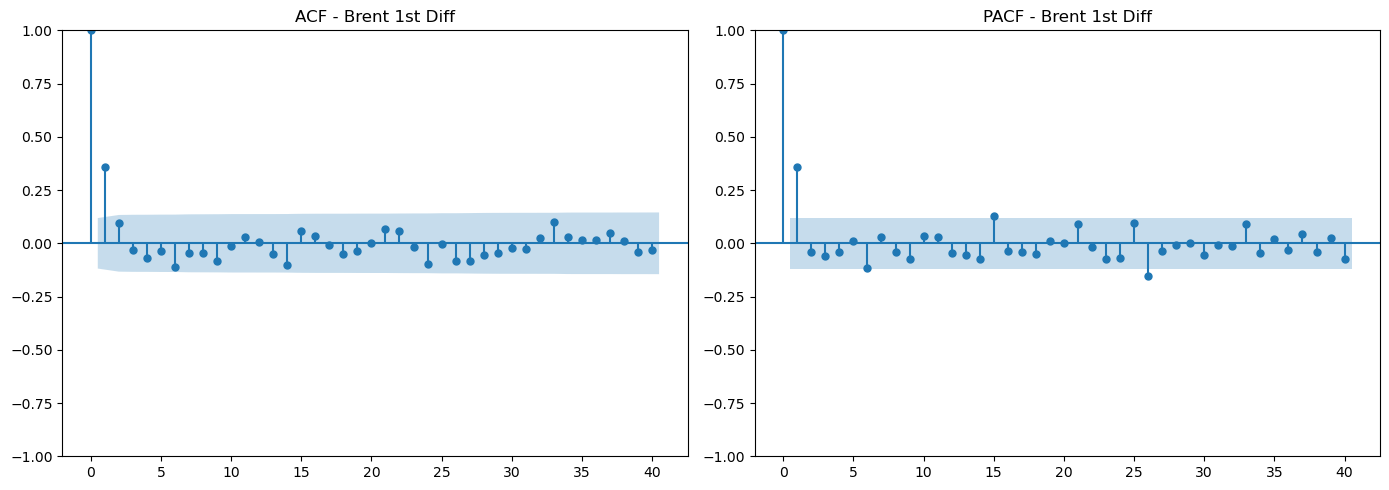

In [ ]:
# Plot raw series
# brent.plot(title='Monthly Brent Crude Price (USD)', figsize=(9, 3))
# plt.ylabel('Price ($/bbl)')
# plt.show()

check_stationarity(brent)

# First difference to achieve stationarity
diff_brent = brent.diff().dropna()
diff_brent.name = "Brent 1st Diff"

check_stationarity(diff_brent)

# Plot differenced series
diff_brent.plot(title='Monthly Brent (1st Diff) Crude Price (USD)', figsize=(9, 3))
plt.ylabel('Price ($/bbl)')
plt.show()

plot_acf_pacf(diff_brent)

### Train/test split and auto_arima

In [ ]:
# Train/test split
train, test = temporal_train_test_split(brent, test_size=24)

# Test both ARIMA and SARIMA
model_auto = auto_arima(
    train,
    seasonal=True,
    m=12,              # monthly seasonality
    d=1,               # fix d=0 from ADF test
    stepwise=True,     # faster grid search
    information_criterion='aic',
    trace=True         # prints models being tested
)

print(model_auto.summary())
# Will return best (p,d,q)(P,D,Q,12)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.49 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1610.210, Time=0.00 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1578.712, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1582.095, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1608.576, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1576.721, Time=0.01 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1578.708, Time=0.05 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1579.836, Time=0.10 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=1578.509, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=1578.564, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1580.123, Time=0.01 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : AIC=inf, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[12]             : AIC=1574.884, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12]             : AIC=1576.873, Time=0.02 sec
 ARIMA(1,1,0)(0,0,1)[12]     

### Fit SARIMA

In [ ]:
# Fit SARIMA — use orders from auto_arima or manually set
sarima_model = SARIMAX(
    train,
    order=model_auto.order,
    seasonal_order=model_auto.seasonal_order
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Brent   No. Observations:                  250
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -785.442
Date:                Sat, 07 Mar 2026   AIC                           1574.884
Time:                        12:31:51   BIC                           1581.919
Sample:                    01-01-2003   HQIC                          1577.716
                         - 10-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3650      0.043      8.471      0.000       0.281       0.449
sigma2        32.1470      2.321     13.849      0.000      27.598      36.696
Ljung-Box (L1) (Q):                   0.03   Jarque-

### Forecast and evaluate

MAE:   11.49
MSE:   174.99
MAPE:  16.15%
sMAPE: 14.52%
MASE:  0.57


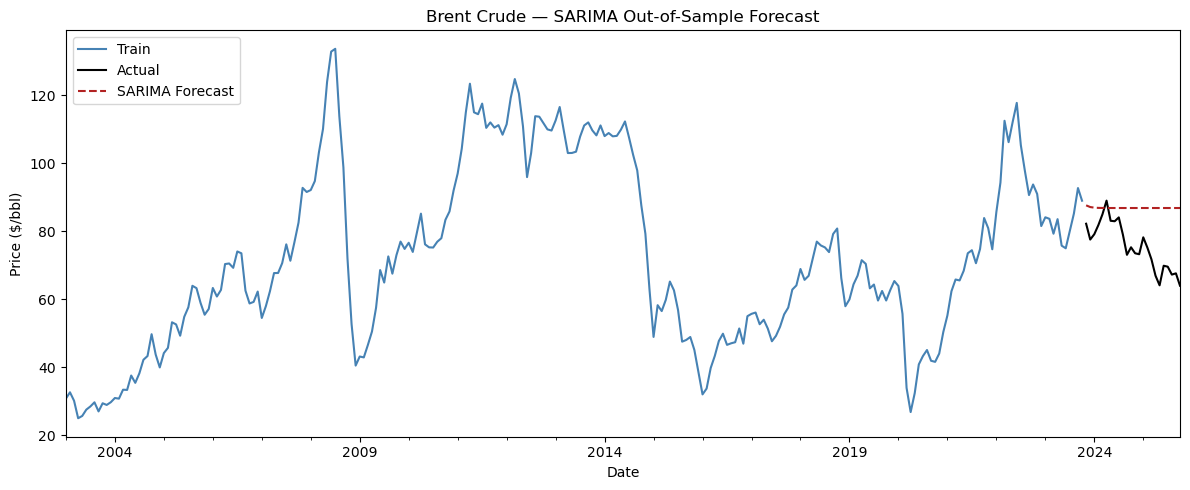

In [ ]:
# Forecast 24 steps ahead
forecast = sarima_fit.forecast(steps=24)
actual_price = test

# Metrics
mae   = mean_absolute_error(actual_price, forecast)
mse   = mean_squared_error(actual_price, forecast)
# rmse  = np.sqrt(mean_squared_error(actual_price, forecast))
mape  = np.mean(np.abs((actual_price - forecast) / actual_price)) * 100
smape = np.mean(2 * np.abs(actual_price - forecast) /
                (np.abs(actual_price) + np.abs(forecast))) * 100

# MASE — seasonal naive benchmark (lag=12) to match Prophet
seasonal_lag = 12
naive_errors = train.values[seasonal_lag:] - train.values[:-seasonal_lag]
mae_naive = np.mean(np.abs(naive_errors))
mase = mae / mae_naive

print(f'MAE:   {mae:.2f}')
print(f'MSE:   {mse:.2f}')
print(f'MAPE:  {mape:.2f}%')
print(f'sMAPE: {smape:.2f}%')
print(f'MASE:  {mase:.2f}')

# Plot
plt.figure(figsize=(12, 5))
train.plot(label='Train', color='steelblue')
actual_price.plot(label='Actual', color='black')
forecast.plot(label='SARIMA Forecast', color='firebrick', linestyle='--')
plt.title('Brent Crude — SARIMA Out-of-Sample Forecast')
plt.ylabel('Price ($/bbl)')
plt.legend()
plt.tight_layout()
plt.show()

### Residual diagnostics

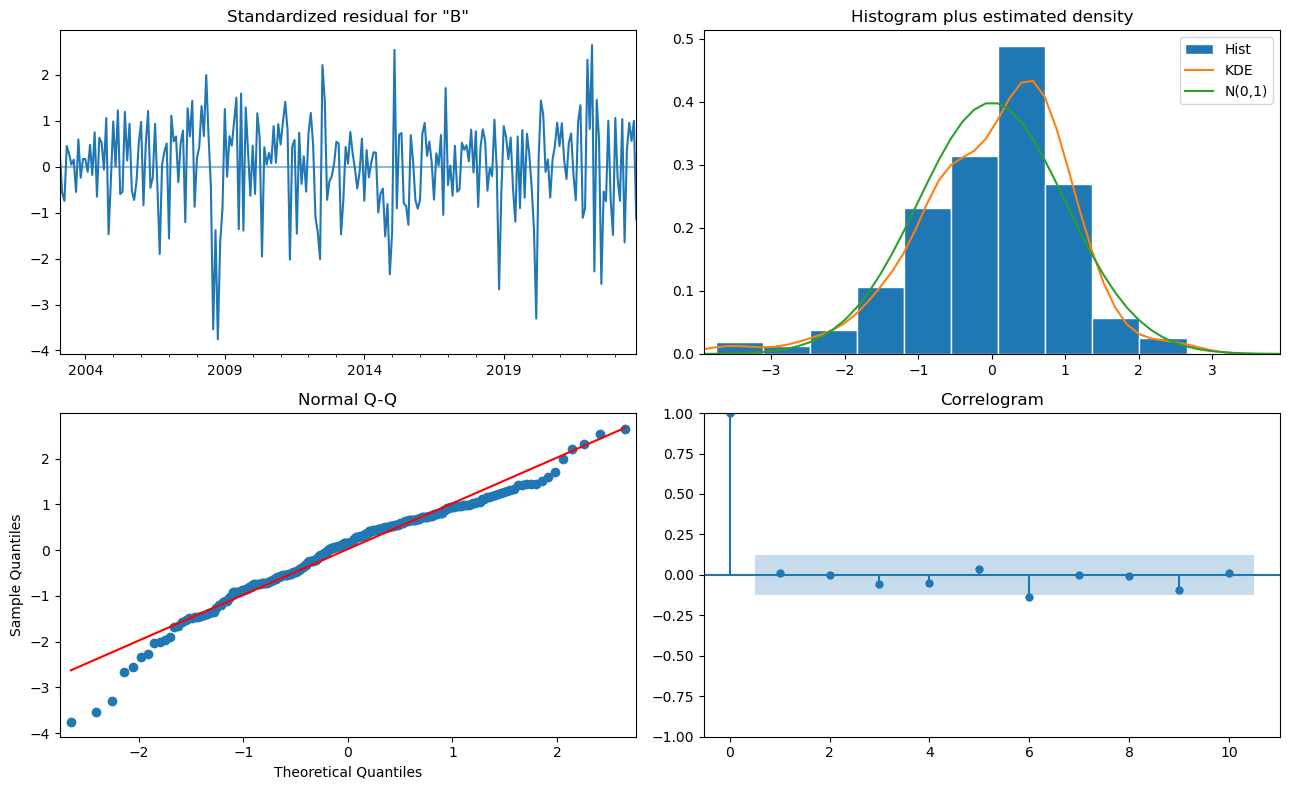

In [ ]:
sarima_fit.plot_diagnostics(figsize=(13, 8))
plt.tight_layout()
plt.show()
# Check: residuals ~ white noise, Q-Q plot near normal, no ACF spikes

# SARIMAX with production and demand as external regressors

### Load production and demand

In [ ]:
# eia = API('add api here')
# prod = eia.get_series(series_id='INTL.57-1-WORL-TBPD.M', start_date='2000-01-01')
# # prod = prod.asfreq('MS')  # monthly start frequency
# prod.name = 'Production'
# prod.dropna(inplace=True)

prod = df['production']
prod.name = "Production"
demand = df['demand']
demand.name = "Demand"

### Exploratory analysis


===== Production =====
ADF statistic: -1.4482, p-value: 0.5589
KPSS statistic: 1.9674, p-value: 0.0100
Strong evidence of non-stationarity

===== Demand =====
ADF statistic: -2.2058, p-value: 0.2042
KPSS statistic: 1.0769, p-value: 0.0100
Strong evidence of non-stationarity

===== Production 1st Diff =====
ADF statistic: -6.4921, p-value: 0.0000
KPSS statistic: 0.0382, p-value: 0.1000
Strong evidence of stationarity

===== Demand 1st Diff =====
ADF statistic: -6.6881, p-value: 0.0000
KPSS statistic: 0.0338, p-value: 0.1000
Strong evidence of stationarity


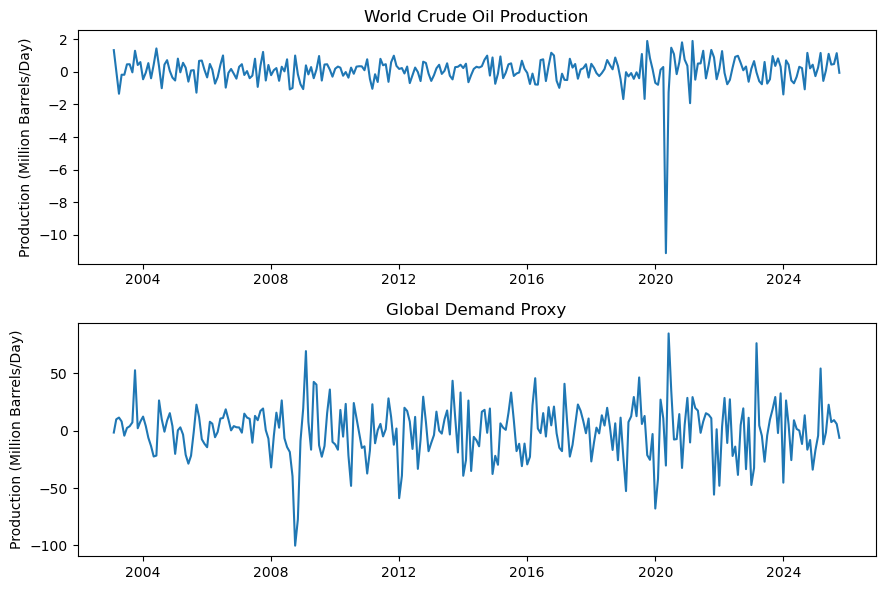

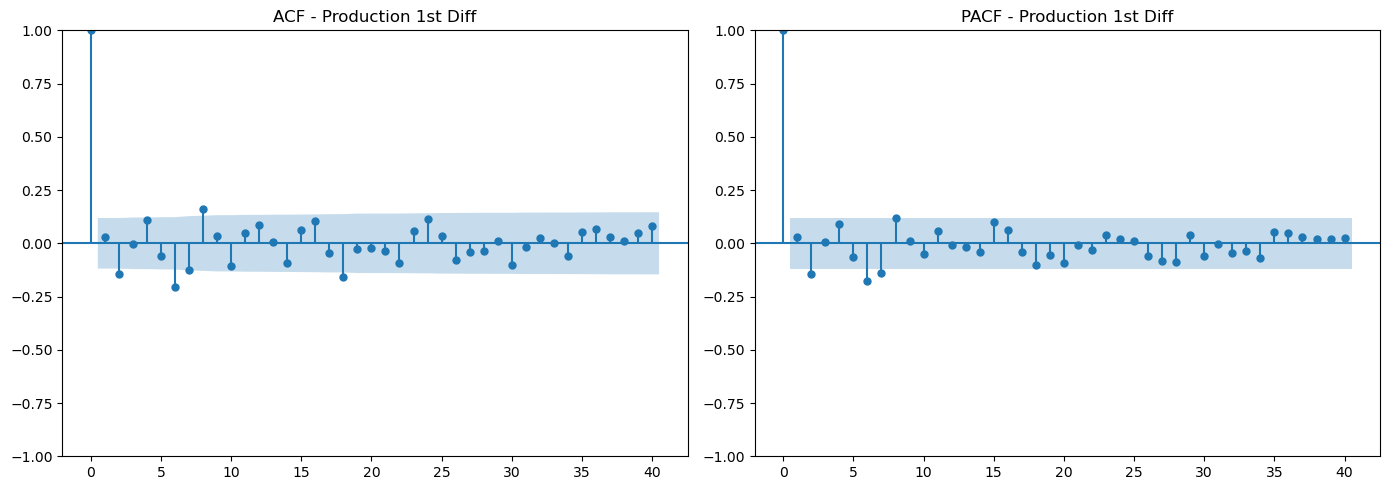

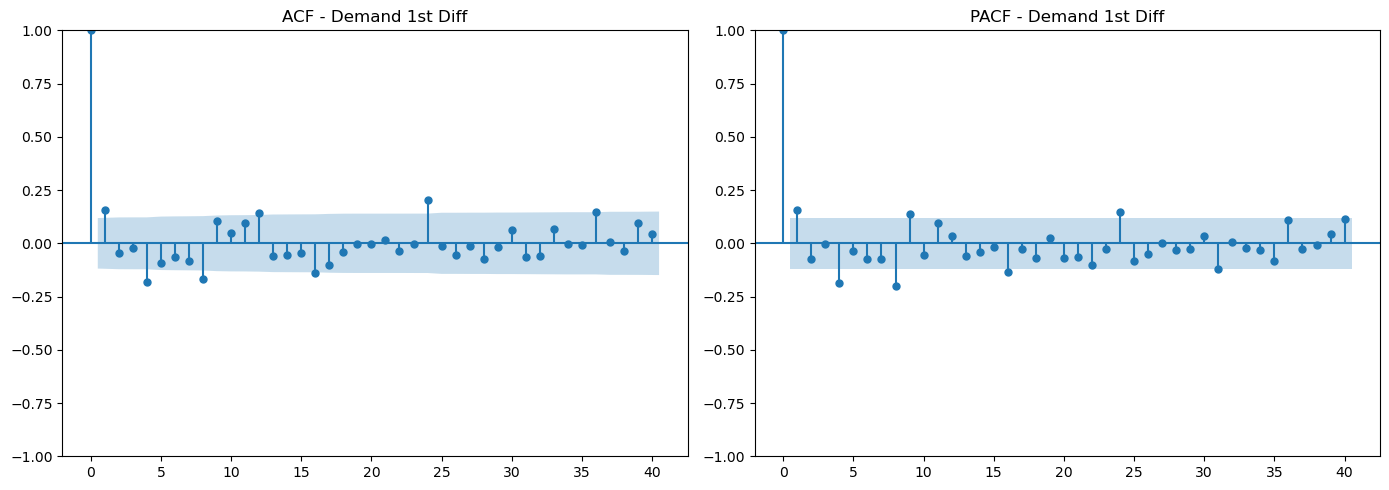

In [ ]:
check_stationarity(prod)
check_stationarity(demand)

# First difference to achieve stationarity
diff_prod = prod.diff().dropna()
diff_prod.name = "Production 1st Diff"
diff_demand = demand.diff().dropna()
diff_demand.name = "Demand 1st Diff"

check_stationarity(diff_prod)
check_stationarity(diff_demand)

# Plot differenced series
fig, axes = plt.subplots(2, 1, figsize=(9, 6))
axes[0].plot(diff_prod)
axes[0].set_title('World Crude Oil Production')
axes[0].set_ylabel('Production (Million Barrels/Day)')
axes[1].plot(diff_demand)
axes[1].set_title('Global Demand Proxy')
axes[1].set_ylabel('Production (Million Barrels/Day)')
plt.tight_layout()
plt.show()

plot_acf_pacf(diff_prod)
plot_acf_pacf(diff_demand)

### Granger causality for lags

Neither production nor demand meaningfully help predict Brent beyond what its own ARIMA structure already captures.

Production → Brent:

- Lag 1: p ≈ 0.07 (marginally significant)

- Lags 2–12: p > 0.48 (no evidence of Granger causality)

Demand → Brent:

- Lag 1: p ≈ 0.09 (marginally significant)

- Lags 2–12: p > 0.18 (no evidence of Granger causality)

In [ ]:
# Test production lags 1-12
max_lag = 12
gc_prod = grangercausalitytests(
    pd.concat([brent, prod], axis=1),
    maxlag=max_lag,
    verbose=True
)

# Test demand lags 1-12
gc_demand = grangercausalitytests(
    pd.concat([brent, demand], axis=1),
    maxlag=max_lag,
    verbose=True
)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.3222  , p=0.0695  , df_denom=270, df_num=1
ssr based chi2 test:   chi2=3.3591  , p=0.0668  , df=1
likelihood ratio test: chi2=3.3386  , p=0.0677  , df=1
parameter F test:         F=3.3222  , p=0.0695  , df_denom=270, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.7098  , p=0.4927  , df_denom=267, df_num=2
ssr based chi2 test:   chi2=1.4461  , p=0.4853  , df=2
likelihood ratio test: chi2=1.4423  , p=0.4862  , df=2
parameter F test:         F=0.7098  , p=0.4927  , df_denom=267, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.5654  , p=0.6383  , df_denom=264, df_num=3
ssr based chi2 test:   chi2=1.7411  , p=0.6278  , df=3
likelihood ratio test: chi2=1.7355  , p=0.6291  , df=3
parameter F test:         F=0.5654  , p=0.6383  , df_denom=264, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.6606  , p=0.6199  

### Lag production and demand

In [ ]:
# It is often better to use a 1-month lag for production and demand.
# This represents the time it takes for supply changes to impact market prices
# and solves the "future value" problem during forecasting.
df['prod_lag1'] = df['production'].shift(1)
df['demand_lag1'] = df['demand'].shift(1)
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 273 entries, 2003-02-01 to 2025-10-01
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Brent        273 non-null    float64
 1   production   273 non-null    float64
 2   demand       273 non-null    float64
 3   prod_lag1    273 non-null    float64
 4   demand_lag1  273 non-null    float64
dtypes: float64(5)
memory usage: 12.8 KB


### Train/test split

In [ ]:
# 24-month test window as used in your baseline
train_exog, test_exog = temporal_train_test_split(df, test_size=24)

y_train_exog = train_exog['Brent']
X_train_exog = train_exog[['prod_lag1', 'demand_lag1']] # External regressors

y_test_exog = test_exog['Brent']
X_test_exog = test_exog[['prod_lag1', 'demand_lag1']]

### Auto_arima with exogenous

In [ ]:
# Re-run auto_arima with exogenous variable
model_auto_exog = auto_arima(
    y_train_exog,
    X=X_train_exog,
    seasonal=True, m=12,
    d=1, trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print(model_auto_exog.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1577.339, Time=0.60 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1600.799, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1572.558, Time=0.08 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1575.058, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1599.242, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1570.565, Time=0.01 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1572.555, Time=0.07 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1573.583, Time=0.19 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=1572.172, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=1572.294, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1573.063, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : AIC=inf, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[12]             : AIC=1568.747, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12]             : AIC=1570.737, Time=0.07 sec
 ARIMA(1,1,0)(0,0,1)[12]

### Fit SARIMAX

In [ ]:
# Fit the SARIMAX model
sarimax_model = SARIMAX(
    y_train_exog,
    exog=X_train_exog,
    order=model_auto_exog.order,
    seasonal_order=model_auto_exog.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)
print(sarimax_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Brent   No. Observations:                  249
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -777.605
Date:                Sat, 07 Mar 2026   AIC                           1563.211
Time:                        12:31:53   BIC                           1577.249
Sample:                    02-01-2003   HQIC                          1568.863
                         - 10-01-2023                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
prod_lag1      -0.3495      0.434     -0.805      0.421      -1.201       0.502
demand_lag1     0.0302      0.017      1.752      0.080      -0.004       0.064
ar.L1           0.3544      0.049      7.162    

### Forecast and evaluate

--- SARIMAX Model Metrics ---
MAE:   11.53
MSE:   171.33
MAPE:  16.15%
sMAPE: 14.56%
MASE:  0.57


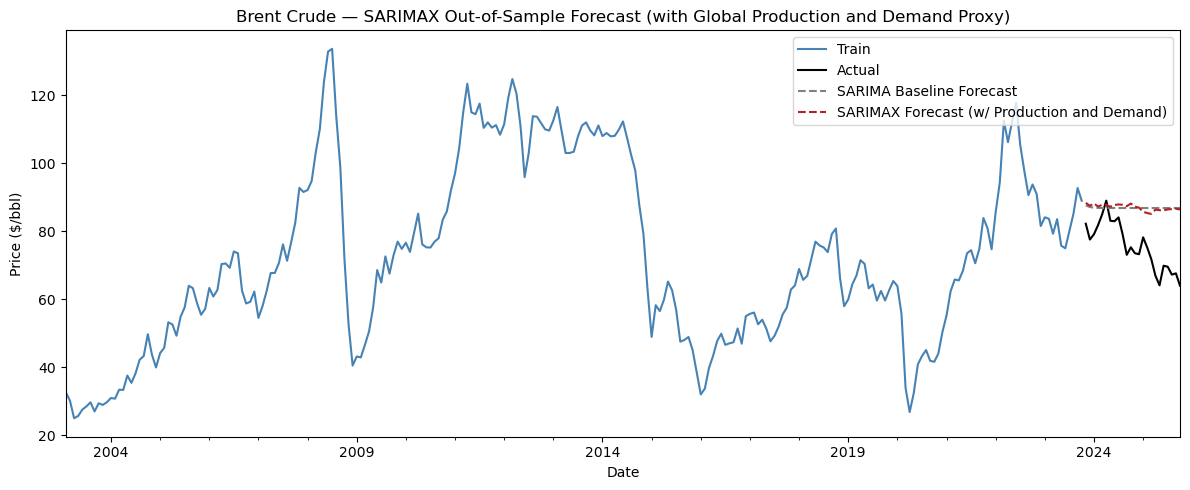

In [ ]:
# Generate forecast
forecast_exog = sarimax_fit.forecast(steps=24, exog=X_test_exog)
actual_price_exog = y_test_exog

# Evaluation (using the same metrics from your notebook)
mae_exog   = mean_absolute_error(actual_price, forecast_exog)
mse_exog   = mean_squared_error(actual_price, forecast_exog)
# rmse  = np.sqrt(mean_squared_error(actual_price, forecast))
mape_exog  = np.mean(np.abs((actual_price - forecast_exog) / actual_price)) * 100
smape_exog = np.mean(2 * np.abs(actual_price - forecast_exog) /
                (np.abs(actual_price) + np.abs(forecast_exog))) * 100

# MASE - seasonal naive benchmark (lag=12)
# use y_train (the target variable) to calculate the naive benchmark
seasonal_lag = 12
naive_errors_exog = y_train_exog.values[seasonal_lag:] - y_train_exog.values[:-seasonal_lag]
mae_naive_exog = np.mean(np.abs(naive_errors_exog))
mase_exog = mae / mae_naive_exog

print(f'--- SARIMAX Model Metrics ---')
print(f'MAE:   {mae_exog:.2f}')
print(f'MSE:   {mse_exog:.2f}')
print(f'MAPE:  {mape_exog:.2f}%')
print(f'sMAPE: {smape_exog:.2f}%')
print(f'MASE:  {mase_exog:.2f}')

# Plotting
plt.figure(figsize=(12, 5))
y_train_exog.plot(label='Train', color='steelblue')
actual_price.plot(label='Actual', color='black')
forecast.plot(label='SARIMA Baseline Forecast', color='gray', linestyle='--')
forecast_exog.plot(label='SARIMAX Forecast (w/ Production and Demand)', color='firebrick', linestyle='--')
plt.title('Brent Crude — SARIMAX Out-of-Sample Forecast (with Global Production and Demand Proxy)')
plt.ylabel('Price ($/bbl)')
plt.legend()
plt.tight_layout()
plt.show()

### Residual diagnostics

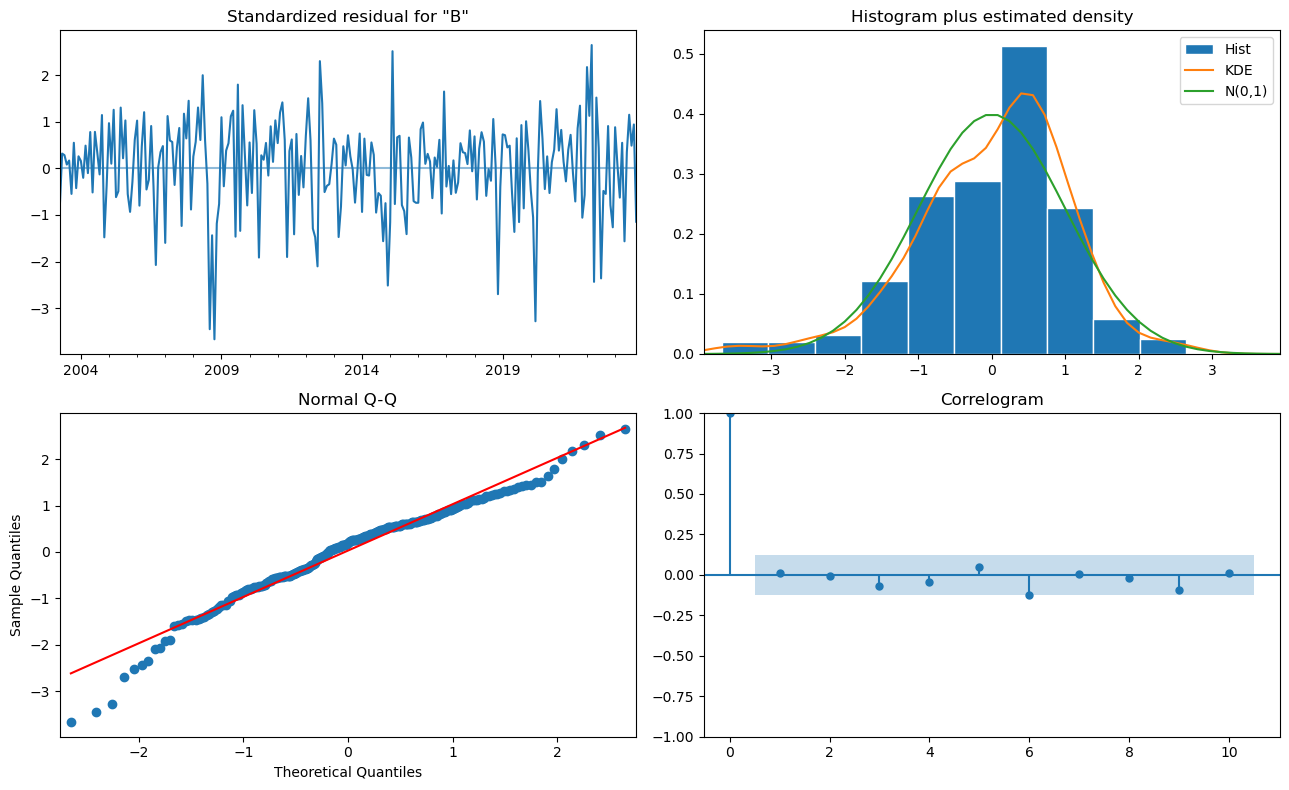

In [ ]:
sarimax_fit.plot_diagnostics(figsize=(13, 8))
plt.tight_layout()
plt.show()
# Check: residuals ~ white noise, Q-Q plot near normal, no ACF spikes

### Output to csv

In [ ]:
# Get SARIMAX forecast with confidence intervals
sarimax_forecast_obj = sarimax_fit.get_forecast(steps=24, exog=X_test_exog, alpha=0.05)
sarimax_forecast = sarimax_forecast_obj.predicted_mean
sarimax_ci = sarimax_forecast_obj.conf_int()

# Match your other CSVs: Date | Actual | Prediction | Lower | Upper
sarimax_results = pd.DataFrame({
    'Date': test.index,
    'Actual': test.values,
    'SARIMAX': sarimax_forecast.values,
    'SARIMAX_lower': sarimax_ci.iloc[:, 0].values,
    'SARIMAX_upper': sarimax_ci.iloc[:, 1].values,
})

sarimax_results.to_csv("sarimax_forecast.csv", index=False)